In [24]:
import numpy as np
import os, sys, json

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import met_brewer as mb
import argparse
import diffrax as dx
import jax

sys.path.append('../')
from plotting_helper_funcs import *
sys.path.append('../models/')
from MA_single_diffrax import *
from MA_single_CaMKK_AMP_ADP_diffrax import *
from utils import *


jax.config.update('jax_enable_x64', True)

plt.style.use('~/.matplotlib/stylelib/custom.mplstyle')

As of 1/7/2025 we are having issues with all models fitting the data properly.

We hypothesized that inclusion of the sensor into the model was causing the issue. We removed the sensor and re-ran GSA, but there was little to no change in the pAMPK/AMPK ratio for that *no sensor* model.

First, we will compare the w/sensor and w/o sensor models to see if there is a difference in the pAMPK/AMPK ratio.

In [25]:
# load samples from GSA
# if 'MA_single_basal' not in locals():
MA_single_basal = np.load('../../../results/GSA/MA_single_sols_basal_GSA.npy')
MA_single_stressed = np.load('../../../results/GSA/MA_single_sols_stressed_GSA.npy')

MA_double_basal = np.load('../../../results/GSA/MA_double_sols_basal_GSA.npy')
MA_double_stressed = np.load('../../../results/GSA/MA_double_sols_stressed_GSA.npy')

MA_single_info = json.load(open('../models/MA_single.json', 'r'))
MA_double_info = json.load(open('../models/MA_double.json', 'r'))

cyto_data, _, cyto_times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', 
                                     to_seconds=False, constant_std=False)

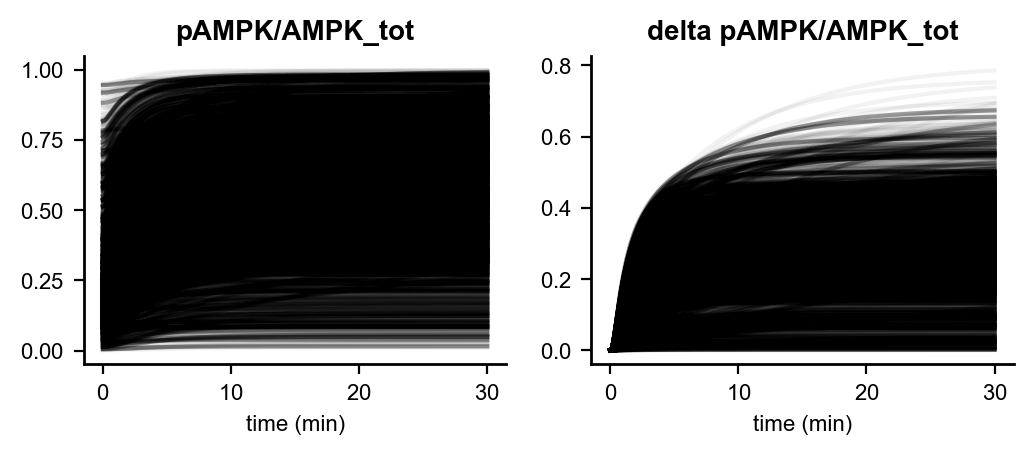

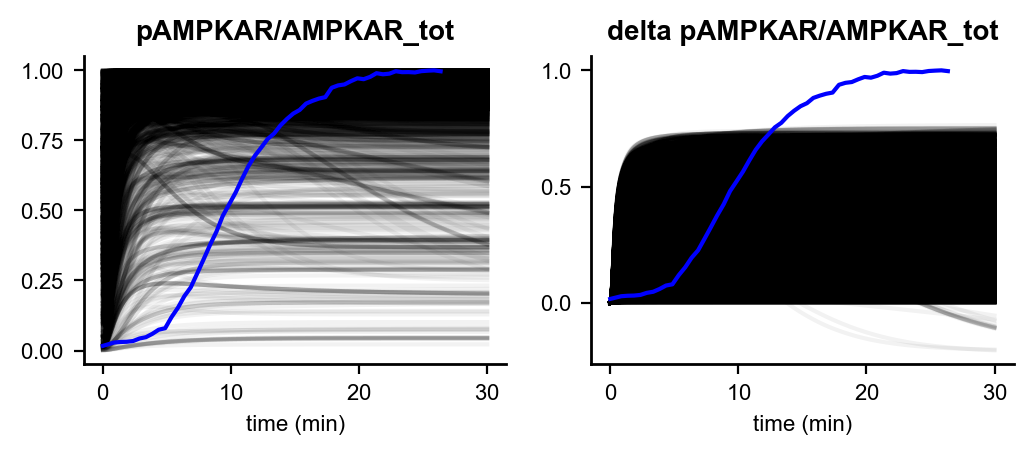

In [28]:
ampk_states = ["AMPK", "AMP_AMPK" , "ADP_AMPK" , "ATP_AMPK", "CaMKK_AMPK" , "CaMKK_AMP_AMPK" , "CaMKK_ADP_AMPK" , "CaMKK_ATP_AMPK" , "LKB1_AMP_AMPK" , "LKB1_ADP_AMPK"]
pAMPK_states = ["pAMPK", "AMP_pAMPK" , "ADP_pAMPK" , "ATP_pAMPK" , "PP_pAMPK" , "PP_ATP_pAMPK", "AMPKAR_AMP_pAMPK"]
ampkar_states = ['AMPKAR', 'AMPKAR_AMP_pAMPK']
pAMPKAR_states = MA_single_info['pampkar_states']

ampk_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in ampk_states]
pAMPK_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in pAMPK_states]
ampkar_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in ampkar_states]
pAMPKAR_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in pAMPKAR_states]

times = np.linspace(0, 1800, 1000)

fig, ax = plt.subplots(1,2, figsize=(6, 2))
for j in range(7168):
    ax[0].plot(times/60, MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)/(MA_single_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0)+MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)), color='black', alpha=0.05)
    ax[1].plot(times/60, MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)/(MA_single_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0)+MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)) - MA_single_stressed[j, np.array(pAMPK_state_idxs), 0].sum(axis=0)/(MA_single_stressed[j, np.array(ampk_state_idxs), 0].sum(axis=0)+MA_single_stressed[j, np.array(pAMPK_state_idxs), 0].sum(axis=0)), color='black', alpha=0.05)
ax[0].set_title('pAMPK/AMPK_tot', fontsize=10)
ax[1].set_title('delta pAMPK/AMPK_tot', fontsize=10)
ax[0].set_xlabel('time (min)', fontsize=8)
ax[1].set_xlabel('time (min)', fontsize=8)
for tick in ax[0].get_xticklabels() + ax[0].get_yticklabels() + ax[1].get_xticklabels() + ax[1].get_yticklabels():
    tick.set_fontsize(8)

fig, ax = plt.subplots(1,2, figsize=(6, 2))
for j in range(7168):
    ax[0].plot(times/60, MA_single_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)/(MA_single_stressed[j, np.array(ampkar_state_idxs), :].sum(axis=0)+MA_single_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)), color='black', alpha=0.05)
    ax[1].plot(times/60, MA_single_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)/(MA_single_stressed[j, np.array(ampkar_state_idxs), :].sum(axis=0)+MA_single_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)) - MA_single_stressed[j, np.array(pAMPKAR_state_idxs), 0].sum(axis=0)/(MA_single_stressed[j, np.array(ampkar_state_idxs), 0].sum(axis=0)+MA_single_stressed[j, np.array(pAMPKAR_state_idxs), 0].sum(axis=0)), color='black', alpha=0.05)
ax[0].set_title('pAMPKAR/AMPKAR_tot', fontsize=10)
ax[1].set_title('delta pAMPKAR/AMPKAR_tot', fontsize=10)
ax[0].set_xlabel('time (min)', fontsize=8)
ax[1].set_xlabel('time (min)', fontsize=8)
for tick in ax[0].get_xticklabels() + ax[0].get_yticklabels() + ax[1].get_xticklabels() + ax[1].get_yticklabels():
    tick.set_fontsize(8)

ax[0].plot(cyto_times, cyto_data, 'b')
ax[1].plot(cyto_times, cyto_data, 'b')

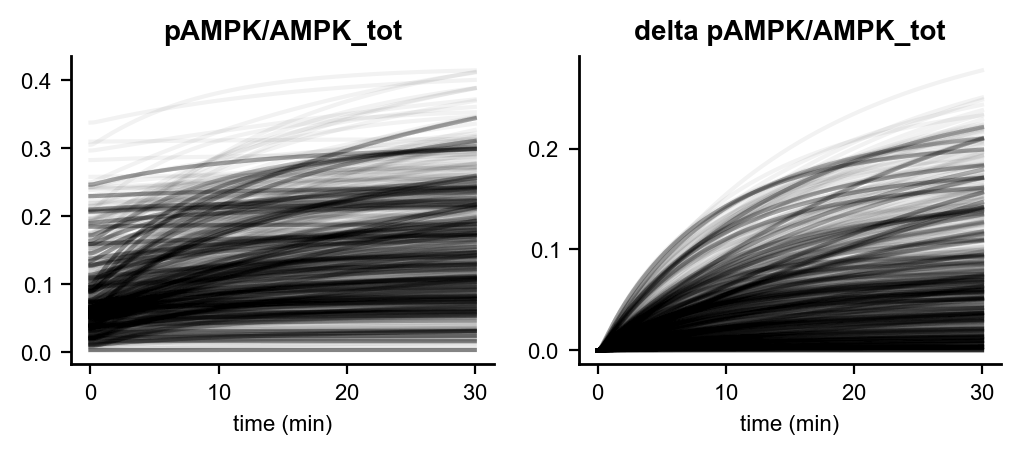

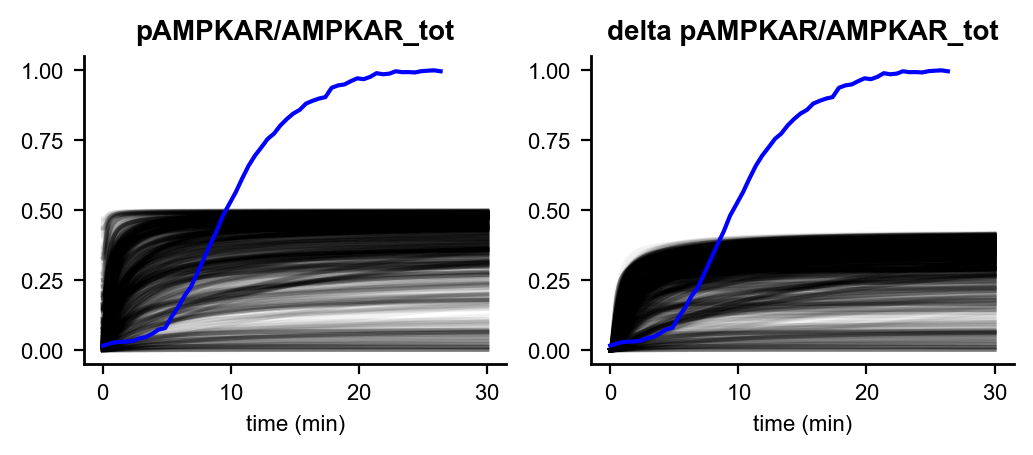

In [29]:
ampk_states = ["AMPK", "pAMPK", "AMP_AMPK", "ADP_AMPK", "ATP_AMPK", "AMP_pAMPK", "ADP_pAMPK", "ATP_pAMPK", "AMP_AMP_AMPK", "AMP_ADP_AMPK", "AMP_ATP_AMPK", "ADP_ADP_AMPK", "ADP_ATP_AMPK", "ATP_ATP_AMPK", "AMP_AMP_pAMPK", "AMP_ADP_pAMPK", "AMP_ATP_pAMPK", "ADP_ADP_pAMPK", "ADP_ATP_pAMPK", "ATP_ATP_pAMPK", "CaMKK_AMPK", "CaMKK_AMP_AMPK", "CaMKK_ADP_AMPK", "CaMKK_ATP_AMPK", "CaMKK_AMP_AMP_AMPK", "CaMKK_AMP_ADP_AMPK", "CaMKK_AMP_ATP_AMPK", "CaMKK_ADP_ADP_AMPK", "CaMKK_ADP_ATP_AMPK", "CaMKK_ATP_ATP_AMPK", "LKB1_AMP_AMPK", "LKB1_ADP_AMPK", "LKB1_AMP_AMP_AMPK", "LKB1_AMP_ADP_AMPK", "LKB1_ADP_ADP_AMPK", "PP_pAMPK", "PP_ATP_pAMPK", "PP_AMP_ATP_pAMPK", "PP_ADP_ATP_pAMPK", "PP_ATP_ATP_pAMPK", "AMPKAR_AMP_pAMPK", "AMPKAR_AMP_AMP_pAMPK", "AMPKAR_AMP_ADP_pAMPK"]
pAMPK_states = ["pAMPK", "AMP_pAMPK", "ADP_pAMPK", "ATP_pAMPK", "AMP_AMP_pAMPK", "AMP_ADP_pAMPK", "AMP_ATP_pAMPK", "ADP_ADP_pAMPK", "ADP_ATP_pAMPK", "ATP_ATP_pAMPK", "PP_pAMPK", "PP_ATP_pAMPK", "PP_AMP_ATP_pAMPK", "PP_ADP_ATP_pAMPK", "PP_ATP_ATP_pAMPK", "AMPKAR_AMP_pAMPK", "AMPKAR_AMP_AMP_pAMPK", "AMPKAR_AMP_ADP_pAMPK"]
ampkar_states = MA_double_info['ampkar_states']
pAMPKAR_states = MA_double_info['pampkar_states']

ampk_state_idxs = [list(MA_double_info['init_conds'].keys()).index(state) for state in ampk_states]
pAMPK_state_idxs = [list(MA_double_info['init_conds'].keys()).index(state) for state in pAMPK_states]
ampkar_state_idxs = [list(MA_double_info['init_conds'].keys()).index(state) for state in ampkar_states]
pAMPKAR_state_idxs = [list(MA_double_info['init_conds'].keys()).index(state) for state in pAMPKAR_states]

times = np.linspace(0, 1800, 1000)

fig, ax = plt.subplots(1,2, figsize=(6, 2))
for j in range(1120):
    ax[0].plot(times/60, MA_double_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)/(MA_double_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0)+MA_double_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)), color='black', alpha=0.05)
    ax[1].plot(times/60, MA_double_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)/(MA_double_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0)+MA_double_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)) - MA_double_stressed[j, np.array(pAMPK_state_idxs), 0].sum(axis=0)/(MA_double_stressed[j, np.array(ampk_state_idxs), 0].sum(axis=0)+MA_double_stressed[j, np.array(pAMPK_state_idxs), 0].sum(axis=0)), color='black', alpha=0.05)
ax[0].set_title('pAMPK/AMPK_tot', fontsize=10)
ax[1].set_title('delta pAMPK/AMPK_tot', fontsize=10)
ax[0].set_xlabel('time (min)', fontsize=8)
ax[1].set_xlabel('time (min)', fontsize=8)
for tick in ax[0].get_xticklabels() + ax[0].get_yticklabels() + ax[1].get_xticklabels() + ax[1].get_yticklabels():
    tick.set_fontsize(8)

fig, ax = plt.subplots(1,2, figsize=(6, 2))
for j in range(1120):
    ax[0].plot(times/60, MA_double_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)/(MA_double_stressed[j, np.array(ampkar_state_idxs), :].sum(axis=0)+MA_double_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)), color='black', alpha=0.05)
    ax[1].plot(times/60, MA_double_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)/(MA_double_stressed[j, np.array(ampkar_state_idxs), :].sum(axis=0)+MA_double_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)) - MA_double_stressed[j, np.array(pAMPKAR_state_idxs), 0].sum(axis=0)/(MA_double_stressed[j, np.array(ampkar_state_idxs), 0].sum(axis=0)+MA_double_stressed[j, np.array(pAMPKAR_state_idxs), 0].sum(axis=0)), color='black', alpha=0.05)
ax[0].set_title('pAMPKAR/AMPKAR_tot', fontsize=10)
ax[1].set_title('delta pAMPKAR/AMPKAR_tot', fontsize=10)
ax[0].set_xlabel('time (min)', fontsize=8)
ax[1].set_xlabel('time (min)', fontsize=8)
for tick in ax[0].get_xticklabels() + ax[0].get_yticklabels() + ax[1].get_xticklabels() + ax[1].get_yticklabels():
    tick.set_fontsize(8)

ax[0].plot(cyto_times, cyto_data, 'b')
ax[1].plot(cyto_times, cyto_data, 'b')

Text(0.5, 1.0, 'delta pAMPKAR/AMPKAR_tot')

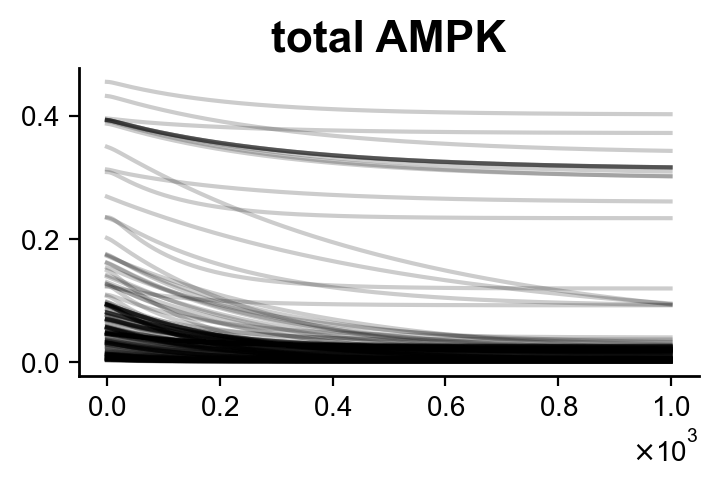

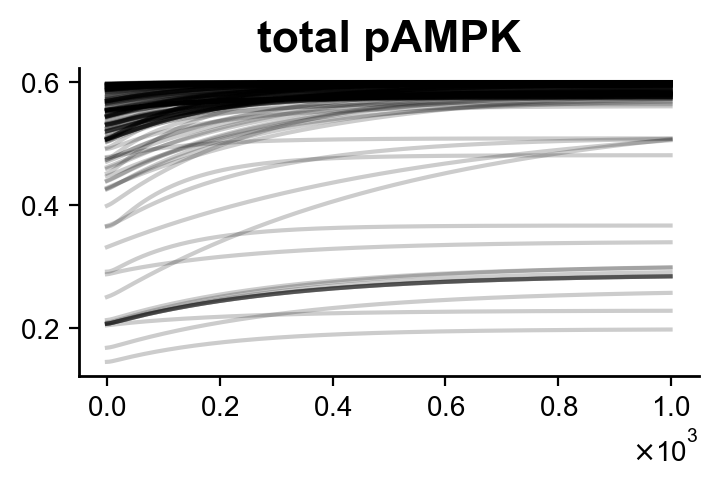

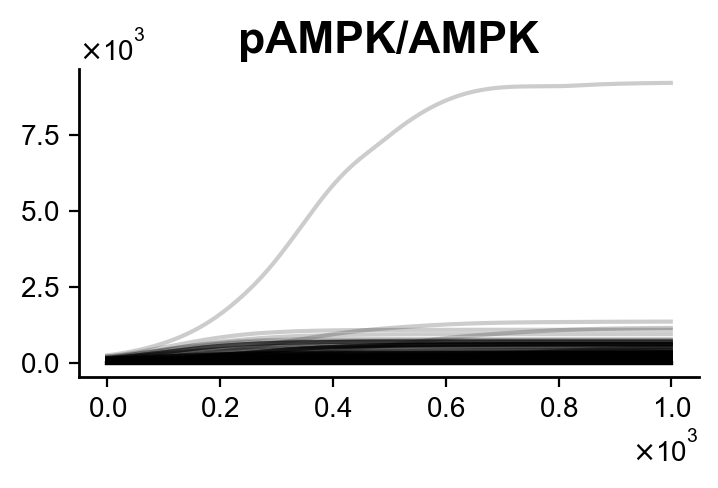

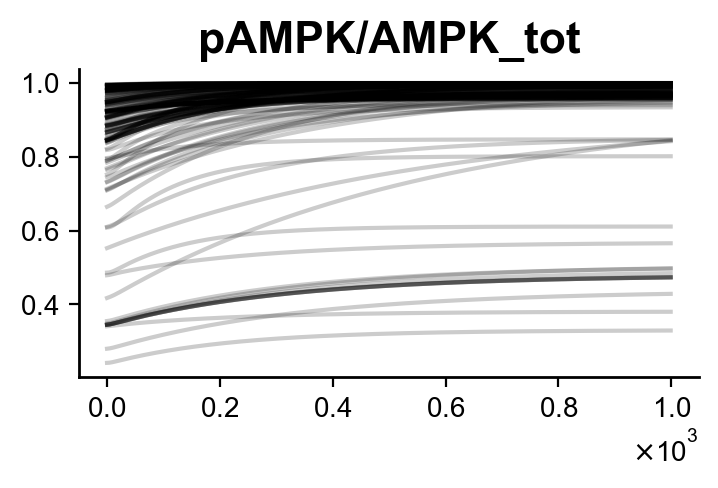

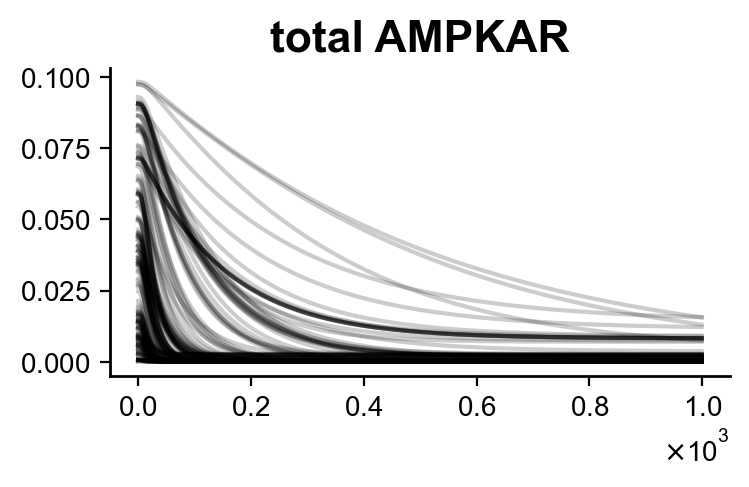

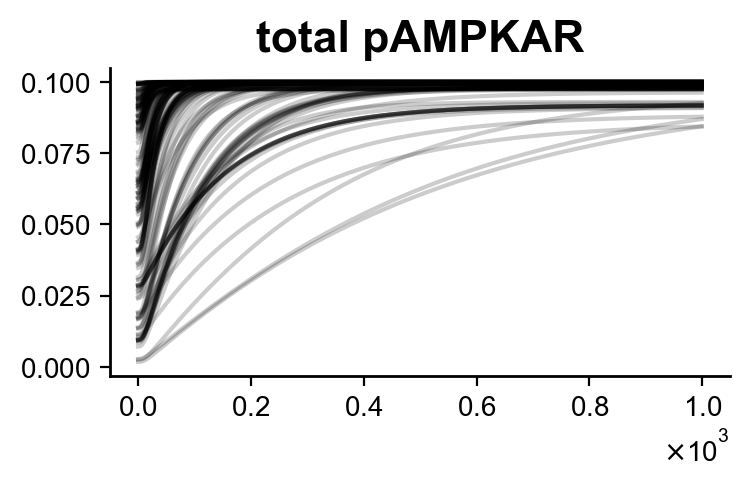

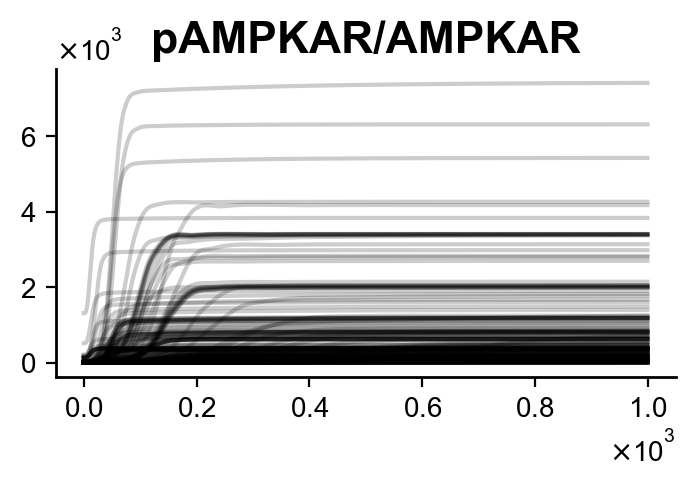

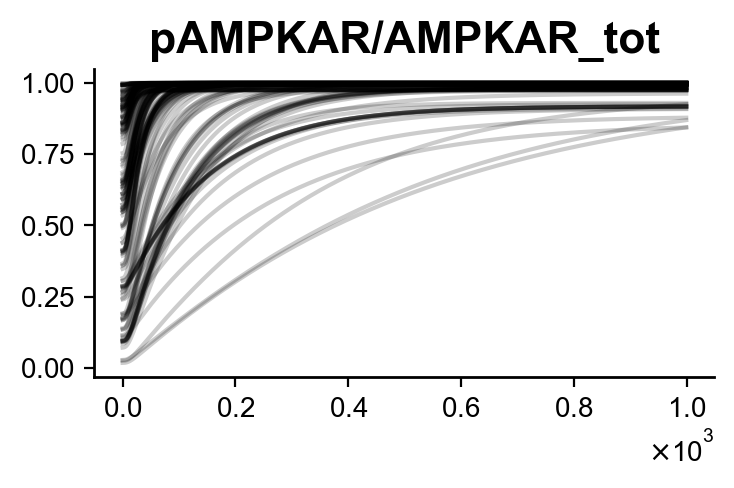

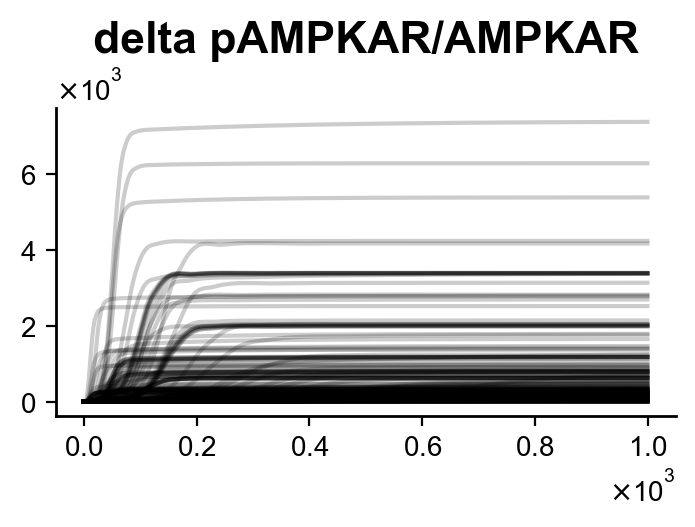

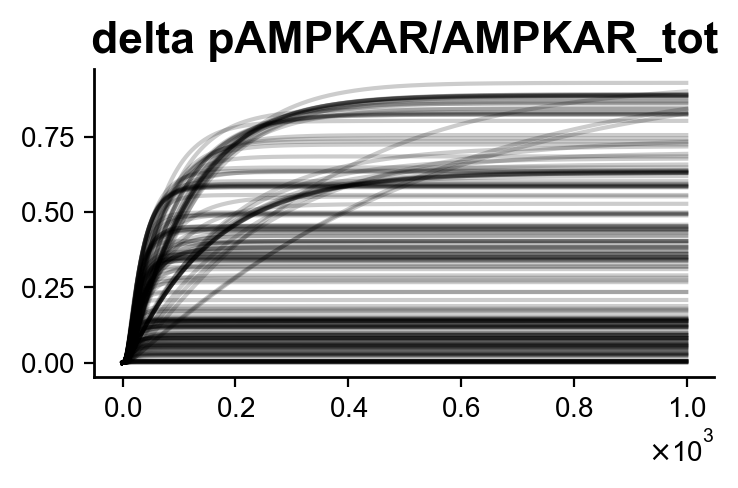

In [181]:
ampk_states = ["AMPK", "AMP_AMPK" , "ADP_AMPK" , "ATP_AMPK", "CaMKK_AMPK" , "CaMKK_AMP_AMPK" , "CaMKK_ADP_AMPK" , "CaMKK_ATP_AMPK" , "LKB1_AMP_AMPK" , "LKB1_ADP_AMPK"]
pAMPK_states = ["pAMPK", "AMP_pAMPK" , "ADP_pAMPK" , "ATP_pAMPK" , "PP_pAMPK" , "PP_ATP_pAMPK", "AMPKAR_AMP_pAMPK"]
ampkar_states = ['AMPKAR', 'AMPKAR_AMP_pAMPK']
pAMPKAR_states = MA_single_info['pampkar_states']

ampk_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in ampk_states]
pAMPK_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in pAMPK_states]
ampkar_state_idx = [list(MA_single_info['init_conds'].keys()).index(state) for state in ampkar_states]
pAMPKAR_state_idx = [list(MA_single_info['init_conds'].keys()).index(state) for state in pAMPKAR_states]

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0) , color='black', alpha=0.2)
ax.set_title('total AMPK')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0) , color='black', alpha=0.2)
ax.set_title('total pAMPK')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)/MA_single_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0), color='black', alpha=0.2)
ax.set_title('pAMPK/AMPK')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)/(MA_single_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0)+MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)), color='black', alpha=0.2)
ax.set_title('pAMPK/AMPK_tot')


fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_stressed[j, np.array(ampkar_state_idx), :].sum(axis=0) , color='black', alpha=0.2)
ax.set_title('total AMPKAR')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0) , color='black', alpha=0.2)
ax.set_title('total pAMPKAR')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0)/(MA_single_stressed[j, np.array(ampkar_state_idx), :].sum(axis=0)), color='black', alpha=0.2)
ax.set_title('pAMPKAR/AMPKAR')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0)/(MA_single_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0) + MA_single_stressed[j, np.array(ampkar_state_idx), :].sum(axis=0)), color='black', alpha=0.2)
ax.set_title('pAMPKAR/AMPKAR_tot')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0)/(MA_single_stressed[j, np.array(ampkar_state_idx), :].sum(axis=0)) - MA_single_stressed[j, np.array(pAMPKAR_state_idx), 0].sum(axis=0)/(MA_single_stressed[j, np.array(ampkar_state_idx), 0].sum(axis=0)), color='black', alpha=0.2)
ax.set_title('delta pAMPKAR/AMPKAR')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0)/(MA_single_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0) + MA_single_stressed[j, np.array(ampkar_state_idx), :].sum(axis=0)) - MA_single_stressed[j, np.array(pAMPKAR_state_idx), 0].sum(axis=0)/(MA_single_stressed[j, np.array(pAMPKAR_state_idx), 0].sum(axis=0) + MA_single_stressed[j, np.array(ampkar_state_idx), 0].sum(axis=0)), color='black', alpha=0.2)
ax.set_title('delta pAMPKAR/AMPKAR_tot')

Text(0.5, 1.0, 'delta pAMPKAR/AMPKAR_tot')

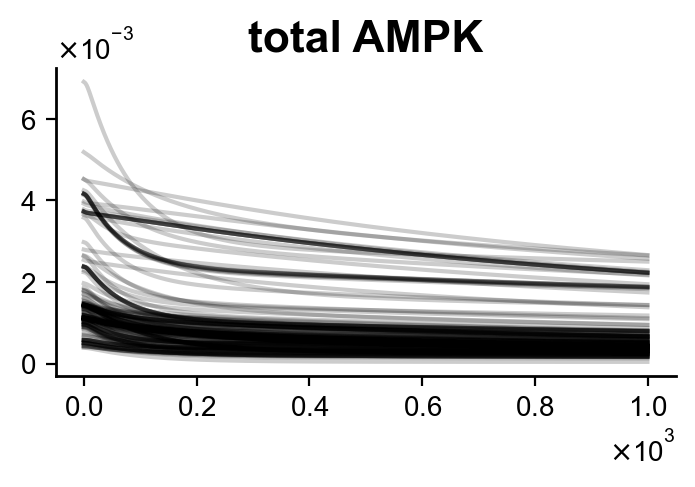

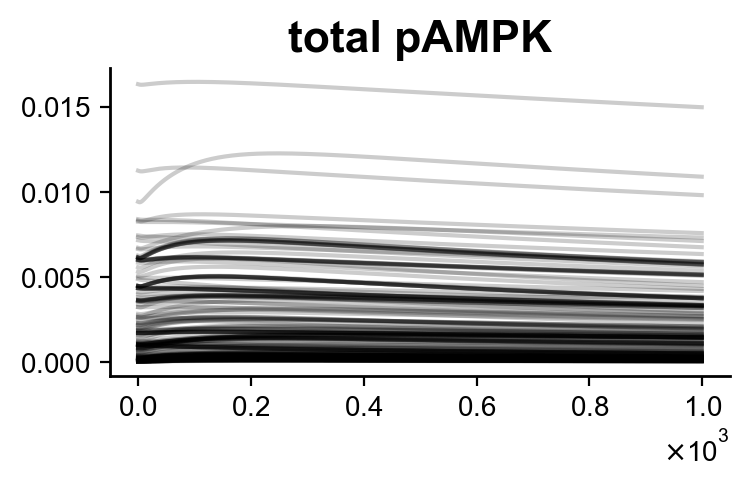

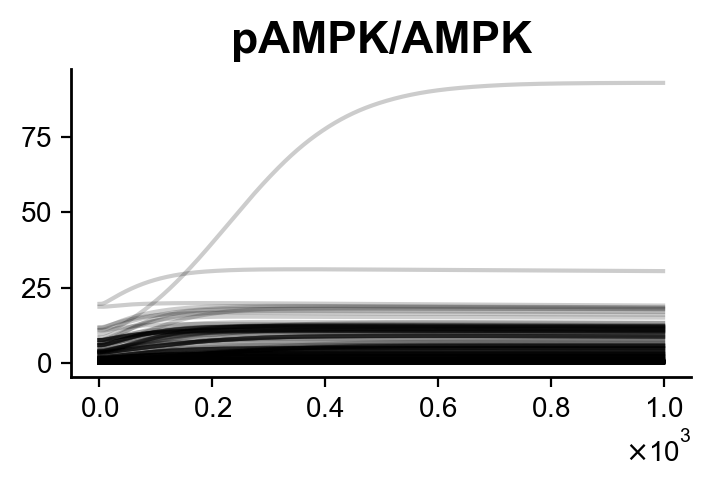

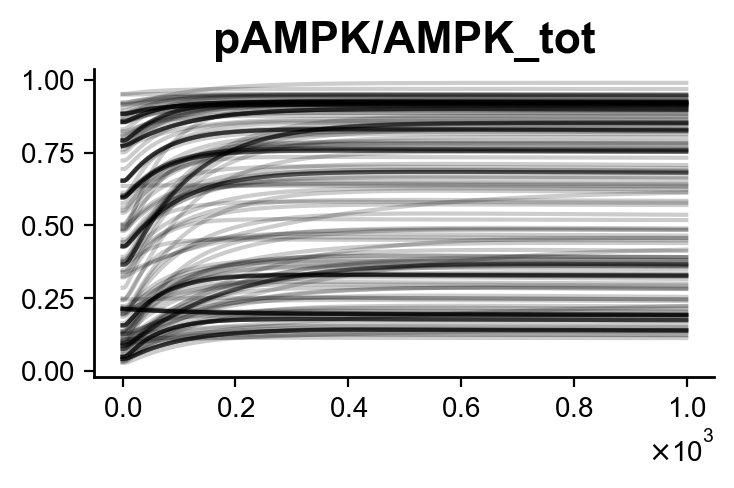

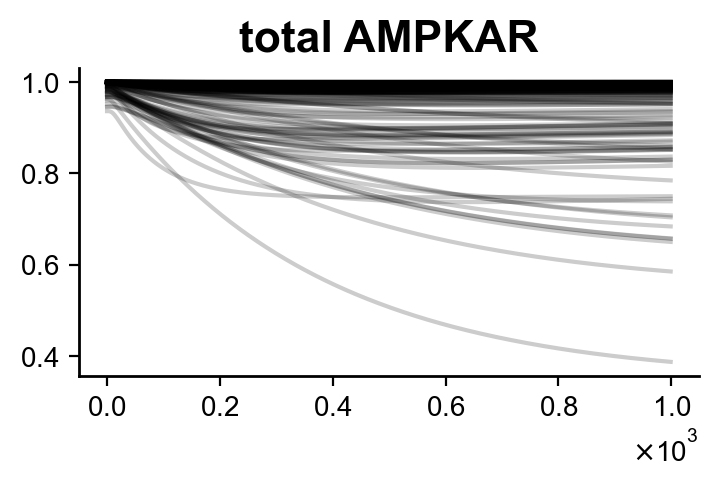

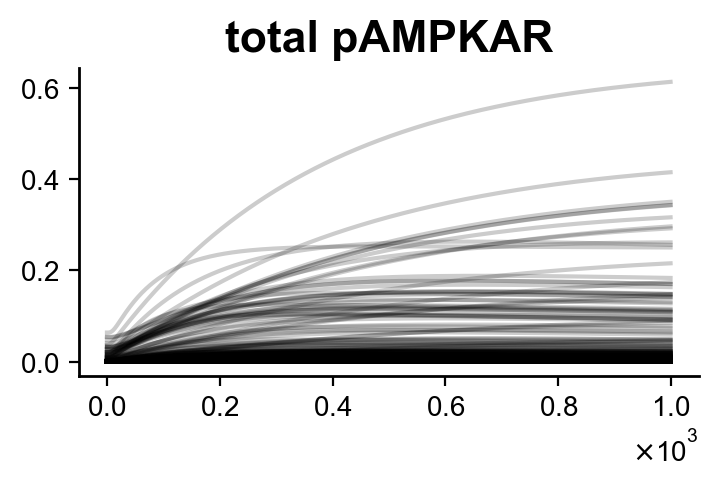

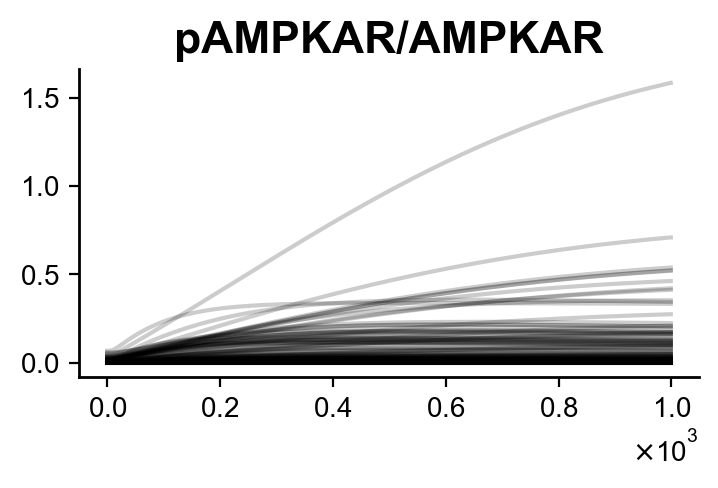

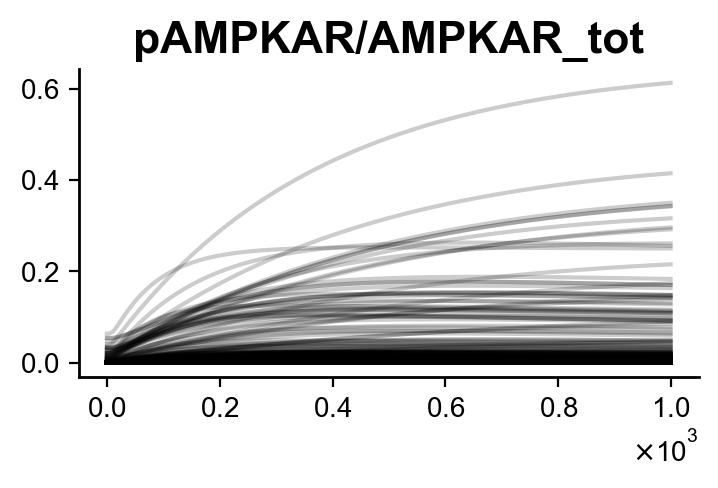

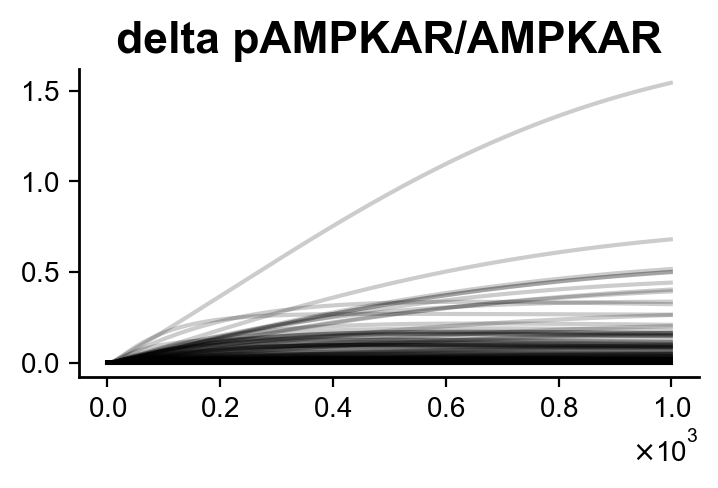

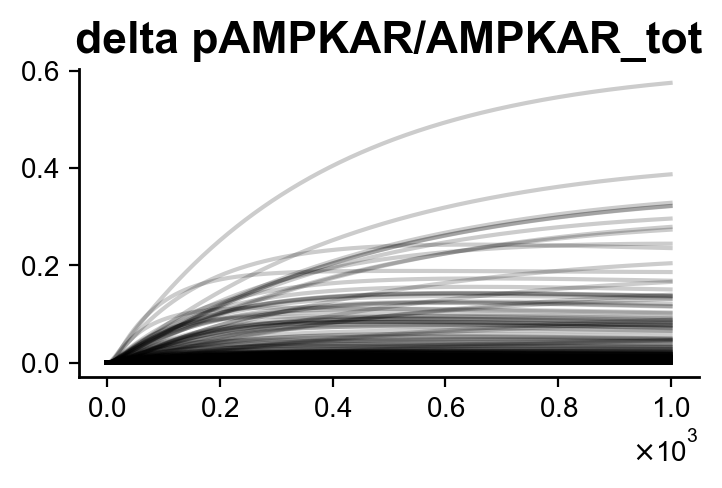

In [46]:
ampk_states = ["AMPK", "AMP_AMPK" , "ADP_AMPK" , "ATP_AMPK", "CaMKK_AMPK", "CaMKK_AMP_AMPK", "CaMKK_ADP_AMPK", "CaMKK_ATP_AMPK", "LKB1_AMP_AMPK" , "LKB1_ADP_AMPK"]
pAMPK_states = ["pAMPK", "AMP_pAMPK" , "ADP_pAMPK" , "ATP_pAMPK" , "PP_pAMPK" , "PP_ATP_pAMPK", "AMPKAR_AMP_pAMPK"]
ampkar_states = ['AMPKAR', 'AMPKAR_AMP_pAMPK']
pAMPKAR_states = MA_single_CaMKK_AMP_ADP_info['pampkar_states']

ampk_state_idxs = [list(MA_single_CaMKK_AMP_ADP_info['init_conds'].keys()).index(state) for state in ampk_states]
pAMPK_state_idxs = [list(MA_single_CaMKK_AMP_ADP_info['init_conds'].keys()).index(state) for state in pAMPK_states]
ampkar_state_idx = [list(MA_single_CaMKK_AMP_ADP_info['init_conds'].keys()).index(state) for state in ampkar_states]
pAMPKAR_state_idx = [list(MA_single_CaMKK_AMP_ADP_info['init_conds'].keys()).index(state) for state in pAMPKAR_states]

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0) , color='black', alpha=0.2)
ax.set_title('total AMPK')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0) , color='black', alpha=0.2)
ax.set_title('total pAMPK')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)/MA_single_CaMKK_AMP_ADP_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0), color='black', alpha=0.2)
ax.set_title('pAMPK/AMPK')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)/(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0)+MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)), color='black', alpha=0.2)
ax.set_title('pAMPK/AMPK_tot')


fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(ampkar_state_idx), :].sum(axis=0) , color='black', alpha=0.2)
ax.set_title('total AMPKAR')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0) , color='black', alpha=0.2)
ax.set_title('total pAMPKAR')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0)/(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(ampkar_state_idx), :].sum(axis=0)), color='black', alpha=0.2)
ax.set_title('pAMPKAR/AMPKAR')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0)/(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0) + MA_single_CaMKK_AMP_ADP_stressed[j, np.array(ampkar_state_idx), :].sum(axis=0)), color='black', alpha=0.2)
ax.set_title('pAMPKAR/AMPKAR_tot')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0)/(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(ampkar_state_idx), :].sum(axis=0)) - MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPKAR_state_idx), 0].sum(axis=0)/(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(ampkar_state_idx), 0].sum(axis=0)), color='black', alpha=0.2)
ax.set_title('delta pAMPKAR/AMPKAR')
# ax.set_yscale('log')

fig, ax = plt.subplots(1,1, figsize=(4, 2))
for j in range(200):
    ax.plot(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0)/(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPKAR_state_idx), :].sum(axis=0) + MA_single_CaMKK_AMP_ADP_stressed[j, np.array(ampkar_state_idx), :].sum(axis=0)) - MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPKAR_state_idx), 0].sum(axis=0)/(MA_single_CaMKK_AMP_ADP_stressed[j, np.array(pAMPKAR_state_idx), 0].sum(axis=0) + MA_single_CaMKK_AMP_ADP_stressed[j, np.array(ampkar_state_idx), 0].sum(axis=0)), color='black', alpha=0.2)
ax.set_title('delta pAMPKAR/AMPKAR_tot')

In [3]:
# load metab params
with open('../models/metabolism_params_Coccimiglio.json', 'r') as f:
    metab_params = json.load(f)
basal_params = list(metab_params['metab_params_basal'].values())
stress_params = list(metab_params['metab_params_stress'].values())

rhs = dx.ODETerm(MA_single(*basal_params))
rhs_stress = dx.ODETerm(MA_single(*stress_params))

y0 = list(MA_single_info['init_conds'].values())
nominal_params = list(MA_single_info['nominal_params'].values())
times = np.linspace(0, 2400, 1000)

solve  = lambda y0, params: solve_traj(rhs, rhs_stress, y0, params, times,
                                    rtol=1e-6, atol=1e-6, 
                                    evnt_rtol=1e-12, evnt_atol=1e-12, 
                                    pcoeff=0.3, icoeff=0.4)

NameError: name 'MA_single_info' is not defined

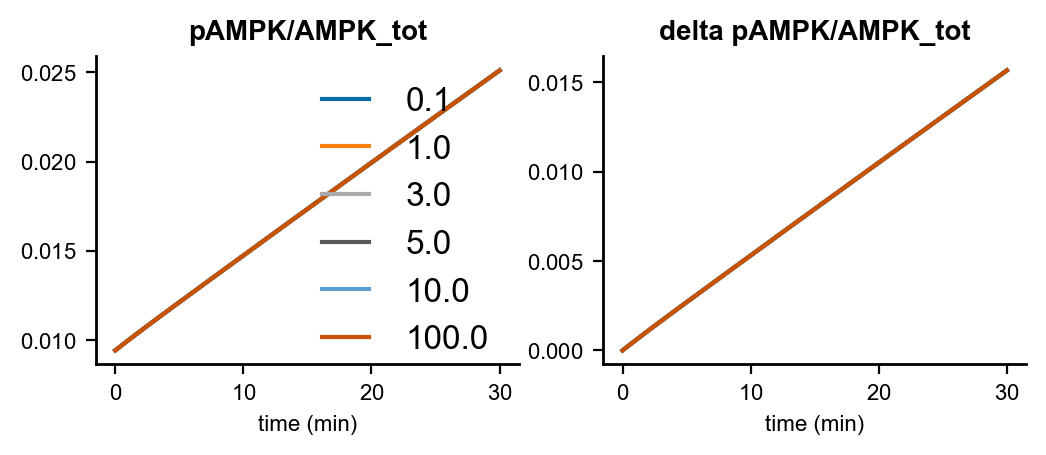

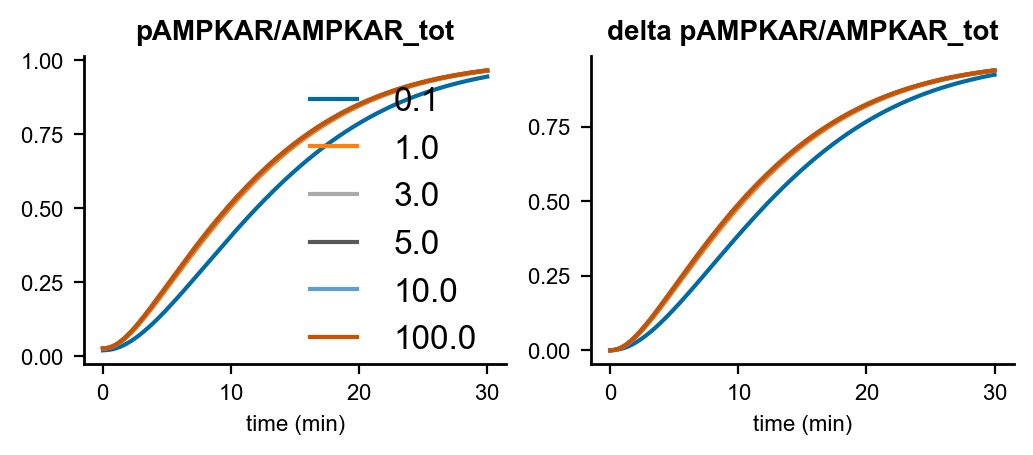

In [29]:
y0 = {'AMP': 0.02,
 'ADP': 1.3,
 'ATP': 8.2,
 'PCr': 22.1,
 'AMPK': 0.6,
 'pAMPK': 0.0,
 'AMP_AMPK': 0.0,
 'ADP_AMPK': 0.0,
 'ATP_AMPK': 0.0,
 'AMP_pAMPK': 0.0,
 'ADP_pAMPK': 0.0,
 'ATP_pAMPK': 0.0,
 'CaMKK': 1.0,
 'CaMKK_AMPK': 0.0,
 'CaMKK_AMP_AMPK': 0.0,
 'CaMKK_ADP_AMPK': 0.0,
 'CaMKK_ATP_AMPK': 0.0,
 'LKB1': 1.0,
 'LKB1_AMP_AMPK': 0.0,
 'LKB1_ADP_AMPK': 0.0,
 'PP': 1.0,
 'PP_pAMPK': 0.0,
 'PP_ATP_pAMPK': 0.0,
 'AMPKAR': 0.1,
 'pAMPKAR': 0.0,
 'AMPKAR_AMP_pAMPK': 0.0,
 'PP1': 1.0,
 'PP1_pAMPKAR': 0.0}

kDephosPP1s = [0.01, 0.001, 0.0001, 0.00001]
kPhosAMPKs = [0.1, 1.0, 3.0, 5.0, 10.0, 100.0]

ampk_states = ["AMPK", "AMP_AMPK" , "ADP_AMPK" , "ATP_AMPK", "CaMKK_AMPK" , "CaMKK_AMP_AMPK" , "CaMKK_ADP_AMPK" , "CaMKK_ATP_AMPK" , "LKB1_AMP_AMPK" , "LKB1_ADP_AMPK"]
pAMPK_states = ["pAMPK", "AMP_pAMPK" , "ADP_pAMPK" , "ATP_pAMPK" , "PP_pAMPK" , "PP_ATP_pAMPK", "AMPKAR_AMP_pAMPK"]
ampkar_states = ['AMPKAR', 'AMPKAR_AMP_pAMPK']
pAMPKAR_states = MA_single_info['pampkar_states']

ampk_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in ampk_states]
pAMPK_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in pAMPK_states]
ampkar_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in ampkar_states]
pAMPKAR_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in pAMPKAR_states]

y0 = list(y0.values())
fig1, ax1 = plt.subplots(1,2, figsize=(6, 2))
fig1, ax2 = plt.subplots(1,2, figsize=(6, 2))

for kPhosAMPK in kPhosAMPKs:
    params = {'kOnAMP': 1.0,
        'kOffAMP': 0.01,
        'kOnADP': 1.0,
        'kOffADP': 0.01,
        'kOnATP': 1.0,
        'kOffATP': 0.01,
        'kOnCaMKK': 1.0,
        'kOffCaMKK': 0.01,
        'kPhosCaMKK': 0.00001,
        'kOnLKB1': 1.0,
        'kOffLKB1': 0.1,
        'kPhosLKB1': 0.000001,
        'kOnPP': 1.0,
        'kOffPP': 10,
        'kDephosPP': 0.0001,
        'kOnAMPK': 1.0,
        'kOffAMPK': 0.01,
        'kPhosAMPK': 3.0,
        'kOnPP1': 1.0,
        'kOffPP1': 10,
        'kDephosPP1': 0.0001}
    
    params['kPhosAMPK'] = kPhosAMPK
    params = list(params.values())

    sol_stress, sol_basal = solve(y0, params)


    ax1[0].plot(times/60, sol_stress[np.array(pAMPK_state_idxs), :].sum(axis=0)/(sol_stress[np.array(ampk_state_idxs), :].sum(axis=0)+sol_stress[np.array(pAMPK_state_idxs), :].sum(axis=0)), label=kPhosAMPK)
    ax1[1].plot(times/60, sol_stress[np.array(pAMPK_state_idxs), :].sum(axis=0)/(sol_stress[np.array(ampk_state_idxs), :].sum(axis=0)+sol_stress[np.array(pAMPK_state_idxs), :].sum(axis=0)) - sol_stress[np.array(pAMPK_state_idxs), 0].sum(axis=0)/(sol_stress[np.array(ampk_state_idxs), 0].sum(axis=0)+sol_stress[np.array(pAMPK_state_idxs), 0].sum(axis=0)), label=kPhosAMPK)
    ax1[0].set_title('pAMPK/AMPK_tot', fontsize=10)
    ax1[1].set_title('delta pAMPK/AMPK_tot', fontsize=10)
    ax1[0].set_xlabel('time (min)', fontsize=8)
    ax1[1].set_xlabel('time (min)', fontsize=8)
    for tick in ax1[0].get_xticklabels() + ax1[0].get_yticklabels() + ax1[1].get_xticklabels() + ax1[1].get_yticklabels():
        tick.set_fontsize(8)

    ax2[0].plot(times/60, sol_stress[np.array(pAMPKAR_state_idxs), :].sum(axis=0)/(sol_stress[np.array(ampkar_state_idxs), :].sum(axis=0)+sol_stress[np.array(pAMPKAR_state_idxs), :].sum(axis=0)), label=kPhosAMPK)
    ax2[1].plot(times/60, sol_stress[np.array(pAMPKAR_state_idxs), :].sum(axis=0)/(sol_stress[np.array(ampkar_state_idxs), :].sum(axis=0)+sol_stress[np.array(pAMPKAR_state_idxs), :].sum(axis=0)) - sol_stress[np.array(pAMPKAR_state_idxs), 0].sum(axis=0)/(sol_stress[np.array(ampkar_state_idxs), 0].sum(axis=0)+sol_stress[np.array(pAMPKAR_state_idxs), 0].sum(axis=0)), label=kPhosAMPK)
    ax2[0].set_title('pAMPKAR/AMPKAR_tot', fontsize=10)
    ax2[1].set_title('delta pAMPKAR/AMPKAR_tot', fontsize=10)
    ax2[0].set_xlabel('time (min)', fontsize=8)
    ax2[1].set_xlabel('time (min)', fontsize=8)
    for tick in ax2[0].get_xticklabels() + ax2[0].get_yticklabels() + ax2[1].get_xticklabels() + ax2[1].get_yticklabels():
        tick.set_fontsize(8)
    
    ax1[0].legend()
    ax2[0].legend()
